EXPLORING CUSTOMER CREDITWORTHINESS

STEPS
1. ANALYSIS

2. FEATURE ENGINEERING

3. MODEL

4. WEB APPLICATION

STEP ONE - ANALYSIS

In [1]:
#Importing necessary libraries

import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns

In [2]:
# Setting Style and Options for Columns and Charts
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

In [3]:
# Loading the Dataset
from google.colab import files
uploaded = files.upload()

Saving german_credit_data.csv to german_credit_data.csv


In [4]:
#Displaying the Dataset
german = pd.read_csv("german_credit_data.csv")
german

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad
...,...,...,...,...,...,...,...,...,...,...,...
995,995,31,female,1,own,little,NaN,1736,12,furniture/equipment,good
996,996,40,male,3,own,little,little,3857,30,car,good
997,997,38,male,2,own,little,NaN,804,12,radio/TV,good
998,998,23,male,2,free,little,little,1845,45,radio/TV,bad


In [5]:
#Inspecting dataset
german.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [6]:
#Inspecting dataset
german.tail()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
995,995,31,female,1,own,little,NaN,1736,12,furniture/equipment,good
996,996,40,male,3,own,little,little,3857,30,car,good
997,997,38,male,2,own,little,NaN,804,12,radio/TV,good
998,998,23,male,2,free,little,little,1845,45,radio/TV,bad
999,999,27,male,2,own,moderate,moderate,4576,45,car,good


In [7]:
german.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


* This shows that among all the 11 columns only two of them have null values in them which are the Saving accounts and Checking account columns

In [8]:
german.shape

(1000, 11)

* This indicates that my dataset has 1000 rows and 11 columns

In [9]:
german.duplicated().sum()

np.int64(0)

In [10]:
german.isna()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,False,False,False,False,False,True,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,True,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
995,False,False,False,False,False,False,True,False,False,False,False
996,False,False,False,False,False,False,False,False,False,False,False
997,False,False,False,False,False,False,True,False,False,False,False
998,False,False,False,False,False,False,False,False,False,False,False


In [11]:
german.isna().sum()

,0
Unnamed: 0,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,183
Checking account,394
Credit amount,0
Duration,0
Purpose,0


In [12]:
#Calculating the percentage of missing values
P_saving = round((german['Saving accounts'].isna().sum()/german.shape[0])*100,2)
P_saving
P_checking = round((german['Checking account'].isna().sum()/german.shape[0])*100,2)
P_checking

np.float64(39.4)

In [13]:
#Calculating the percentage of missing values for all columns
round((german.isna().sum()/german.shape[0])*100,2)

,0
Unnamed: 0,0.0
Age,0.0
Sex,0.0
Job,0.0
Housing,0.0
Saving accounts,18.3
Checking account,39.4
Credit amount,0.0
Duration,0.0
Purpose,0.0


In [14]:
#Finding the empty row
german[german.isnull().any(axis=1)]

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
2,2,49,male,1,own,little,NaN,2096,12,education,good
5,5,35,male,1,free,NaN,NaN,9055,36,education,good
6,6,53,male,2,own,quite rich,NaN,2835,24,furniture/equipment,good
8,8,61,male,1,own,rich,NaN,3059,12,radio/TV,good
...,...,...,...,...,...,...,...,...,...,...,...
991,991,34,male,1,own,moderate,NaN,1569,15,radio/TV,good
992,992,23,male,1,rent,NaN,little,1936,18,radio/TV,good
994,994,50,male,2,own,NaN,NaN,2390,12,car,good
995,995,31,female,1,own,little,NaN,1736,12,furniture/equipment,good


In [15]:
#Filling the missing values
german['Saving accounts'] = german['Saving accounts'].fillna('No_Account')
german['Checking account'] = german['Checking account'].fillna('No_Account')
german.isna().sum()

,0
Unnamed: 0,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,0
Checking account,0
Credit amount,0
Duration,0
Purpose,0


In [16]:
#Checking the Datatype
german.dtypes

,0
Unnamed: 0,int64
Age,int64
Sex,object
Job,int64
Housing,object
Saving accounts,object
Checking account,object
Credit amount,int64
Duration,int64
Purpose,object


In [17]:
#Changing data types
german['Sex']=german['Sex'].astype('category')
german['Saving accounts']=german['Saving accounts'].astype('category')
german['Checking account']=german['Checking account'].astype('category')
german['Risk']=german['Risk'].astype('category')
german['Housing']=german['Housing'].astype('category')
german['Job']=german['Job'].astype('category')
german['Purpose']=german['Purpose'].astype('category')

In [18]:
german.dtypes

,0
Unnamed: 0,int64
Age,int64
Sex,category
Job,category
Housing,category
Saving accounts,category
Checking account,category
Credit amount,int64
Duration,int64
Purpose,category


In [19]:
german

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,No_Account,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,No_Account,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad
...,...,...,...,...,...,...,...,...,...,...,...
995,995,31,female,1,own,little,No_Account,1736,12,furniture/equipment,good
996,996,40,male,3,own,little,little,3857,30,car,good
997,997,38,male,2,own,little,No_Account,804,12,radio/TV,good
998,998,23,male,2,free,little,little,1845,45,radio/TV,bad


In [20]:
german.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   Unnamed: 0        1000 non-null   int64   
 1   Age               1000 non-null   int64   
 2   Sex               1000 non-null   category
 3   Job               1000 non-null   category
 4   Housing           1000 non-null   category
 5   Saving accounts   1000 non-null   category
 6   Checking account  1000 non-null   category
 7   Credit amount     1000 non-null   int64   
 8   Duration          1000 non-null   int64   
 9   Purpose           1000 non-null   category
 10  Risk              1000 non-null   category
dtypes: category(7), int64(4)
memory usage: 39.5 KB


In [21]:
german.describe()

,Unnamed: 0,Age,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,35.546000,3271.258000,20.903000
std,288.819436,11.375469,2822.736876,12.058814
min,0.000000,19.000000,250.000000,4.000000
25%,249.750000,27.000000,1365.500000,12.000000
50%,499.500000,33.000000,2319.500000,18.000000
75%,749.250000,42.000000,3972.250000,24.000000
max,999.000000,75.000000,18424.000000,72.000000


In [22]:
german.drop(columns = 'Unnamed: 0', inplace = True)

In [23]:
german

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,No_Account,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,No_Account,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad
...,...,...,...,...,...,...,...,...,...,...
995,31,female,1,own,little,No_Account,1736,12,furniture/equipment,good
996,40,male,3,own,little,little,3857,30,car,good
997,38,male,2,own,little,No_Account,804,12,radio/TV,good
998,23,male,2,free,little,little,1845,45,radio/TV,bad


In [24]:
german.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

#Inspecting the Distribution of Age, Credit amount and Duration Column

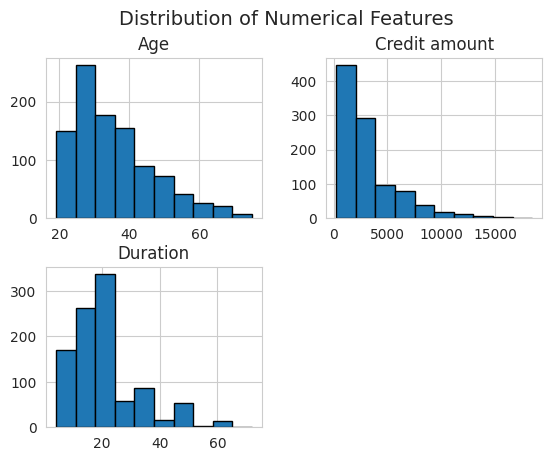

In [25]:
import matplotlib.pyplot as plt
german[["Age", "Credit amount", "Duration"]].hist(bins = 10, edgecolor = "black")
plt.suptitle("Distribution of Numerical Features", fontsize = 14)
plt.show()

# Inspecting outliers within the numerical columns, Age, Credit amount and Duration

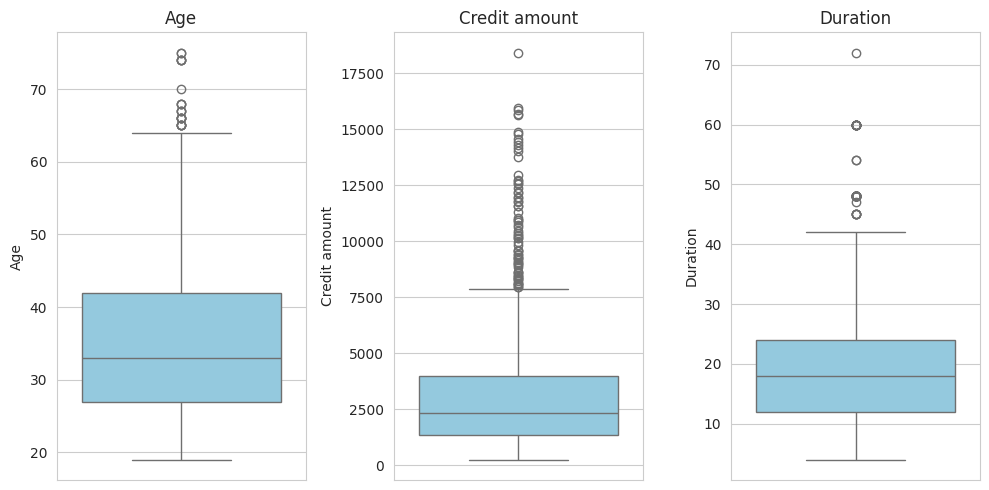

In [26]:
plt.figure(figsize = (10,5))
for i , col in enumerate(["Age", "Credit amount", "Duration"]):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(y = german[col], color = "skyblue")
    plt.title(col)

plt.tight_layout()
plt.show()

In [27]:
german.query("Duration >= 60")

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
29,63,male,2,own,little,little,6836,60,business,bad
134,21,female,2,own,moderate,No_Account,10144,60,radio/TV,good
255,27,male,1,own,No_Account,moderate,7418,60,radio/TV,good
332,24,female,3,own,moderate,moderate,7408,60,car,bad
373,63,male,3,free,No_Account,No_Account,13756,60,car,good
374,60,female,3,free,moderate,moderate,14782,60,vacation/others,bad
616,27,male,3,free,No_Account,moderate,9157,60,radio/TV,good
637,21,male,2,own,little,No_Account,15653,60,radio/TV,good
672,42,male,3,own,little,No_Account,10366,60,car,good
677,24,male,2,own,moderate,moderate,5595,72,radio/TV,bad


In [28]:
categorical_cols = ["Sex", "Job", "Housing", "Saving accounts", "Checking account", "Purpose"]

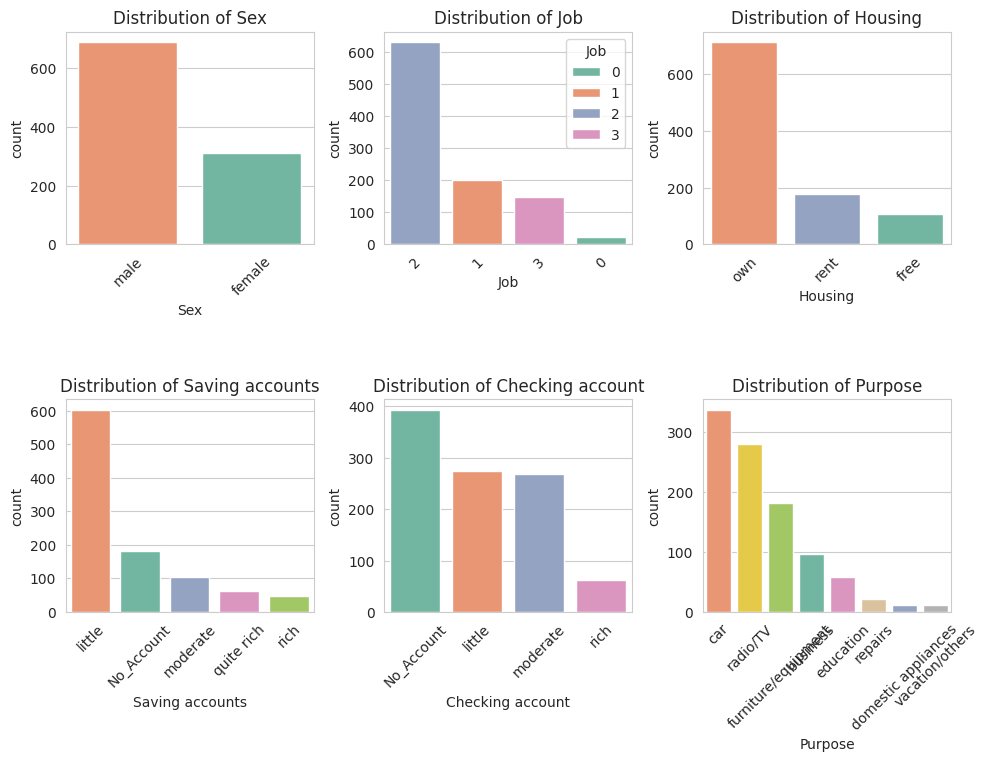

In [29]:
plt.figure(figsize = (10, 10))
for i , col in enumerate(categorical_cols):
    plt.subplot(3, 3, i + 1)
    sns.countplot(data = german, x = col, hue = col, palette = "Set2", order = german[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation = 45)

plt.tight_layout()
plt.show()

# Inspecting Correlation of some relevant columns

In [30]:
corr = german[["Age", "Job", "Credit amount", "Duration"]].corr()

In [31]:
corr

,Age,Job,Credit amount,Duration
Age,1.000000,0.015673,0.032716,-0.036136
Job,0.015673,1.000000,0.285385,0.210910
Credit amount,0.032716,0.285385,1.000000,0.624984
Duration,-0.036136,0.210910,0.624984,1.000000


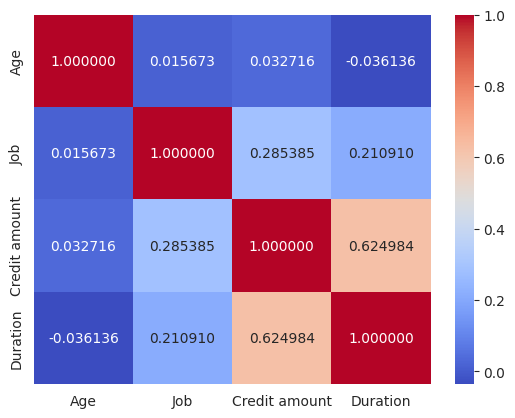

In [32]:
sns.heatmap(corr, annot = True, cmap = "coolwarm", fmt = "2f")
plt.show()

In [33]:
german.groupby("Job")["Credit amount"].mean()

/tmp/ipykernel_7554/3660386786.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  german.groupby("Job")["Credit amount"].mean()


,Credit amount
Job,
0,2745.136364
1,2358.520000
2,3070.965079
3,5435.493243


In [34]:
german.groupby("Sex")["Credit amount"].mean()

/tmp/ipykernel_7554/2416310475.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  german.groupby("Sex")["Credit amount"].mean()


,Credit amount
Sex,
female,2877.774194
male,3448.040580


In [35]:
pd.pivot_table(german, values= "Credit amount", index = "Housing", columns = "Purpose")

/tmp/ipykernel_7554/3470900524.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pd.pivot_table(german, values= "Credit amount", index = "Housing", columns = "Purpose")


Purpose,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
Housing,,,,,,,,
free,4931.800000,5834.181818,NaN,4387.266667,4100.181818,2417.333333,2750.666667,7227.250
own,3800.592105,3329.949772,1546.5,2198.647059,3107.459016,2540.493392,2866.000000,8700.375
rent,5614.125000,3487.968254,1255.5,2931.000000,2727.354167,2199.763158,1522.000000,NaN


#Inspecting relationship between the columns Age, credit amount and Duration

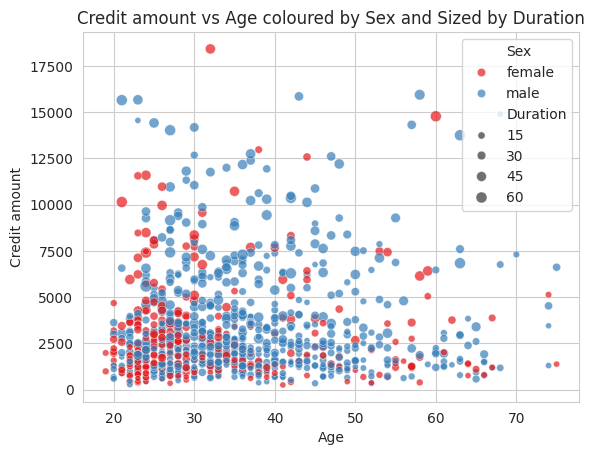

In [36]:
sns.scatterplot(data = german, x = "Age", y = "Credit amount", hue = "Sex", size = "Duration", alpha = 0.7, palette = "Set1")
plt.title("Credit amount vs Age coloured by Sex and Sized by Duration")
plt.show()

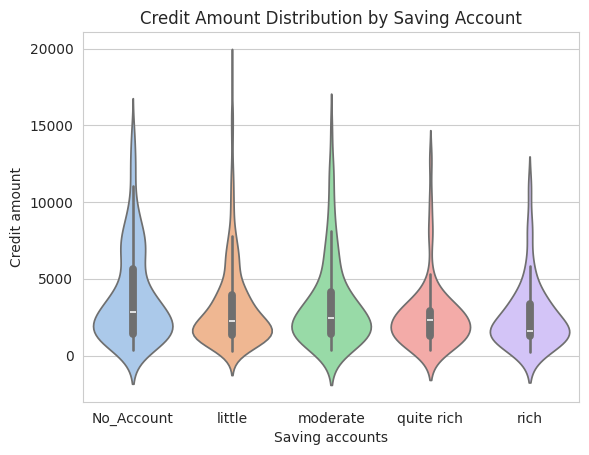

In [37]:
sns.violinplot(data = german, x = "Saving accounts", y = "Credit amount", hue = "Saving accounts", palette = "pastel")
plt.title("Credit Amount Distribution by Saving Account")
plt.show()

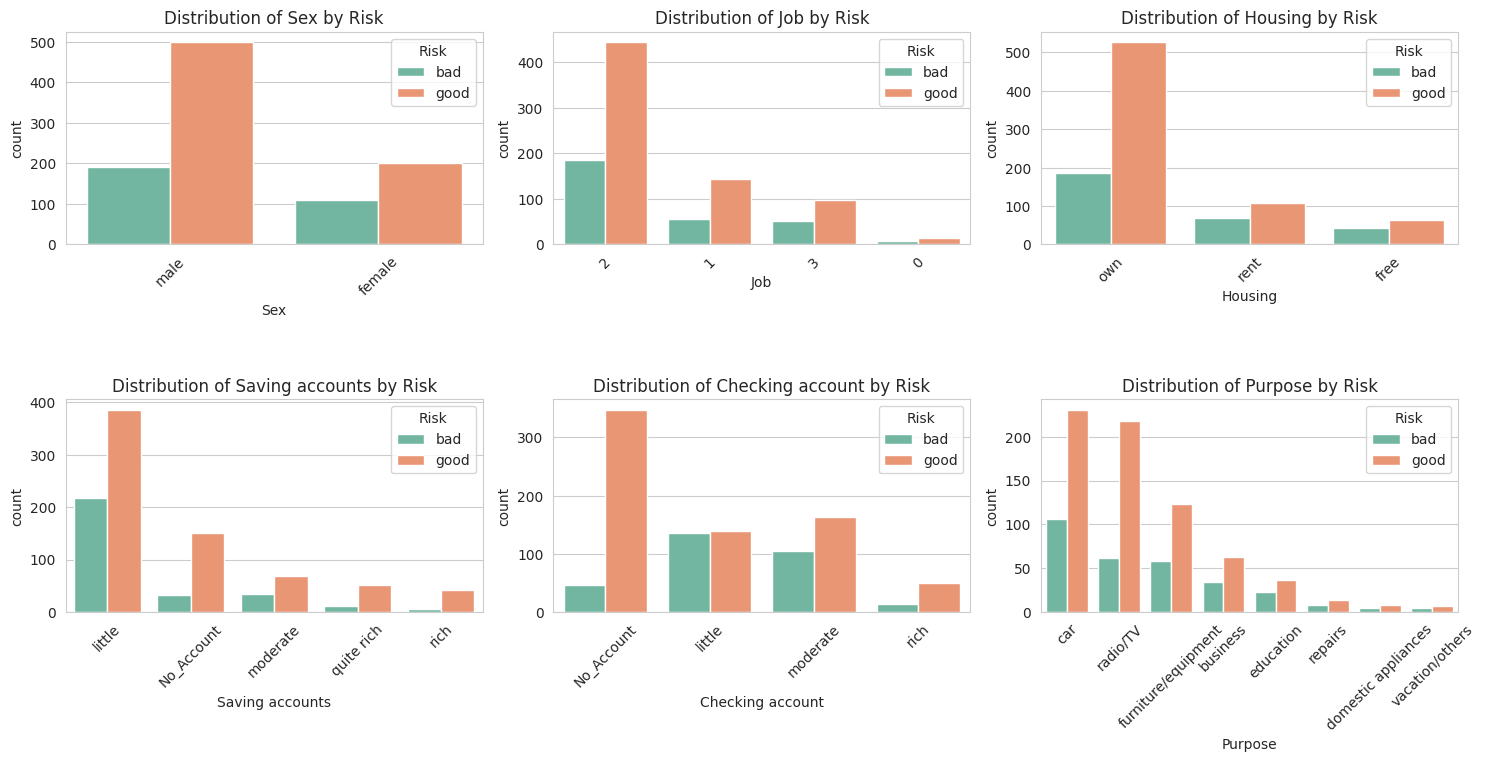

In [38]:
plt.figure(figsize = (15, 10))
for i , col in enumerate(categorical_cols):
    plt.subplot(3, 3, i + 1)
    sns.countplot(data = german, x = col, hue = "Risk", palette = "Set2", order = german[col].value_counts().index)
    plt.title(f"Distribution of {col} by Risk")
    plt.xticks(rotation = 45)

plt.tight_layout()
plt.show()

STEP 2

FEATURE ENGINEERING

In [39]:
features = ["Age", "Sex", "Job", "Housing", "Saving accounts", "Checking account", "Credit amount", "Duration"]

In [40]:
target = "Risk"

In [41]:
german_model = german[features + [target]].copy()

In [42]:
german_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,67,male,2,own,No_Account,little,1169,6,good
1,22,female,2,own,little,moderate,5951,48,bad
2,49,male,1,own,little,No_Account,2096,12,good
3,45,male,2,free,little,little,7882,42,good
4,53,male,2,free,little,little,4870,24,bad


* STEP 3
MODEL

In [43]:
from sklearn.preprocessing import LabelEncoder
import joblib

In [44]:
cat_cols = german_model.select_dtypes(include = "category").columns.drop("Risk")

In [45]:
german_model.dtypes

,0
Age,int64
Sex,category
Job,category
Housing,category
Saving accounts,category
Checking account,category
Credit amount,int64
Duration,int64
Risk,category


In [46]:
cat_cols

Index(['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account'], dtype='object')

In [47]:
le_dict = {}

In [48]:
for col in cat_cols:
  le = LabelEncoder()
  german_model[col] = le.fit_transform(german_model[col])
  le_dict[col] = le
  joblib.dump(le, f"{col}_encoder.pkl")

In [49]:
le_target = LabelEncoder()

In [50]:
target

'Risk'

In [51]:
german_model[target] = le_target.fit_transform(german_model[target])

In [52]:
german_model[target].value_counts()

,count
Risk,
1,700
0,300


In [53]:
joblib.dump(le_target, "target_encoder.pkl")

['target_encoder.pkl']

In [54]:
german_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,67,1,2,1,0,1,1169,6,1
1,22,0,2,1,1,2,5951,48,0
2,49,1,1,1,1,0,2096,12,1
3,45,1,2,0,1,1,7882,42,1
4,53,1,2,0,1,1,4870,24,0


In [55]:
from sklearn.model_selection import train_test_split

In [56]:
X = german_model.drop(target, axis = 1)

In [57]:
y = german_model[target]

In [58]:
X

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration
0,67,1,2,1,0,1,1169,6
1,22,0,2,1,1,2,5951,48
2,49,1,1,1,1,0,2096,12
3,45,1,2,0,1,1,7882,42
4,53,1,2,0,1,1,4870,24
...,...,...,...,...,...,...,...,...
995,31,0,1,1,1,0,1736,12
996,40,1,3,1,1,1,3857,30
997,38,1,2,1,1,0,804,12
998,23,1,2,0,1,1,1845,45


In [59]:
y

,Risk
0,1
1,0
2,1
3,1
4,0
...,...
995,1
996,1
997,1
998,0


In [60]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state = 45)

In [61]:
X_train.shape

(800, 8)

In [62]:
X_test.shape

(200, 8)

In [63]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

In [64]:
def train_model(model, param_grid, X_train, y_train, X_test, y_test):
    grid = GridSearchCV(model, param_grid, cv = 5, scoring = "accuracy", n_jobs = -1)
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    return best_model, acc, grid.best_params_


In [65]:
dt = DecisionTreeClassifier(random_state = 45, class_weight = "balanced")
dt_param_grid = {
    "max_depth" : [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [66]:
best_dt, acc_dt, params_dt = train_model(dt, dt_param_grid, X_train, y_train, X_test, y_test)

In [67]:
print("Decision Tree Accuracy", acc_dt)

Decision Tree Accuracy 0.655


In [68]:
print("Best Parameters", params_dt)

Best Parameters {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [69]:
rf = RandomForestClassifier(random_state = 45, class_weight = "balanced", n_jobs = -1)
rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth" : [5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [70]:
best_rf, acc_rf, params_rf = train_model(rf, rf_param_grid, X_train, y_train, X_test, y_test)

In [71]:
print("Random Forest Accuracy", acc_rf)

Random Forest Accuracy 0.725


In [72]:
print("Best Parameters", params_rf)

Best Parameters {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


In [73]:
et = ExtraTreesClassifier(random_state = 45, class_weight = "balanced", n_jobs = -1)
et_param_grid = {
    "n_estimators": [100, 200],
    "max_depth" : [5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [74]:
best_et, acc_et, params_et = train_model(et, et_param_grid, X_train, y_train, X_test, y_test)

In [75]:
print("Extra Tree Accuracy", acc_et)

Extra Tree Accuracy 0.69


In [76]:
print("Best Parameters", params_et)

Best Parameters {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [77]:
xgb = XGBClassifier(random_state = 45, scale_pos_weight = (y_train == 0).sum()/(y_train == 1).sum(), use_label_encoder = False, eval_metric = "logloss")
xgb_param_grid = {
    "n_estimators": [100, 200],
    "max_depth" : [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2],
    "subsample" : [0.7, 1],
    "colsample_bytree" : [0.7, 1]
}

In [78]:
best_xgb, acc_xgb, params_xgb = train_model(xgb, xgb_param_grid, X_train, y_train, X_test, y_test)

/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [20:26:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [79]:
print("XGB Accuracy", acc_xgb)

XGB Accuracy 0.675


In [80]:
print("Best Parameters", params_xgb)

Best Parameters {'colsample_bytree': 0.7, 'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.7}


* Using the Random Forest model because it gave the best output results

In [81]:
best_rf.predict(X_test)

array([1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0,
       1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0,
       1, 0])

In [84]:
joblib.dump(best_rf, "random_forest_credit_model.pkl")

['random_forest_credit_model.pkl']

In [85]:
import os
os.listdir()

['.config',
 'Saving accounts_encoder.pkl',
 'german_credit_data.csv',
 'Checking account_encoder.pkl',
 'Sex_encoder.pkl',
 'random_forest_credit_model.pkl',
 'Job_encoder.pkl',
 'target_encoder.pkl',
 'Housing_encoder.pkl',
 'sample_data']

In [86]:
from google.colab import files

files.download('random_forest_credit_model.pkl')
files.download('Saving accounts_encoder.pkl')
files.download('Checking account_encoder.pkl')
files.download('Sex_encoder.pkl')
files.download('Job_encoder.pkl')
files.download('Housing_encoder.pkl')
files.download('target_encoder.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>